## How Are In-Demand Skills Trending for Data Scientists

### Import Libraries and Data

In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# Loading Data
df = pd.read_csv(r'C:\Users\baw61\Downloads\job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Filter for Most Recent Completed Year

In [5]:
# filter job_posted_date for 2025
df = df[df['job_posted_date'].dt.year == 2025]

### Create Pivot Table

In [6]:
df_DS_US = df[(df['job_title'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_US['job_posted_month_no'] = df_DS_US['job_posted_date'].dt.month
df_DS_US_explode = df_DS_US.explode('job_skills')

df_DS_US_pivot = df_DS_US_explode.pivot_table(index= 'job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DS_US_pivot.loc['Total'] = df_DS_US_pivot.sum()

df_DS_US_pivot = df_DS_US_pivot[df_DS_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_DS_US_pivot = df_DS_US_pivot.drop('Total')

df_DS_US_pivot

job_skills,python,sql,r,tableau,aws,power bi,azure,spark,scikit-learn,pytorch,...,angular.js,db2,qt,powershell,sqlite,trello,unify,tidyverse,vue,wire
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,60,47,30,19,14,7,14,15,7,12,...,0,1,0,1,0,0,0,0,0,0
2,144,79,84,64,36,42,3,38,1,14,...,0,0,0,0,0,0,0,0,0,0
3,150,114,101,35,33,32,27,9,37,24,...,0,0,1,0,0,0,0,1,0,0
4,93,60,30,18,21,14,23,18,20,17,...,1,0,0,0,0,1,0,0,0,0
5,68,43,25,17,24,17,20,18,12,18,...,0,0,0,0,0,0,0,0,0,0
6,79,66,42,22,32,18,27,26,25,20,...,0,0,0,0,0,0,0,0,0,0
7,54,35,28,10,23,11,17,15,15,13,...,0,0,0,0,0,0,0,0,0,0
8,105,69,59,35,15,25,10,15,15,11,...,0,0,0,0,1,0,0,0,0,0
9,37,25,16,5,15,10,11,7,7,6,...,0,0,0,0,0,0,0,0,1,0


### Calculate Percentage and Create Pivot Table

In [7]:
DS_totals = df_DS_US.groupby('job_posted_month_no').size()

df_DS_US_percent = df_DS_US_pivot.iloc[:12].div(DS_totals/100, axis=0)

df_DS_US_percent = df_DS_US_percent.reset_index()
df_DS_US_percent['job_posted_month'] = df_DS_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format= '%m').strftime('%b'))
df_DS_US_percent = df_DS_US_percent.set_index('job_posted_month')
df_DS_US_percent = df_DS_US_percent.drop(columns='job_posted_month_no')

df_DS_US_percent

job_skills,python,sql,r,tableau,aws,power bi,azure,spark,scikit-learn,pytorch,...,angular.js,db2,qt,powershell,sqlite,trello,unify,tidyverse,vue,wire
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,67.415730,52.808989,33.707865,21.348315,15.730337,7.865169,15.730337,16.853933,7.865169,13.483146,...,0.000000,1.123596,0.000000,1.123596,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,73.469388,40.306122,42.857143,32.653061,18.367347,21.428571,1.530612,19.387755,0.510204,7.142857,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,83.798883,63.687151,56.424581,19.553073,18.435754,17.877095,15.083799,5.027933,20.670391,13.407821,...,0.000000,0.000000,0.558659,0.000000,0.000000,0.000000,0.000000,0.558659,0.000000,0.000000
Apr,87.735849,56.603774,28.301887,16.981132,19.811321,13.207547,21.698113,16.981132,18.867925,16.037736,...,0.943396,0.000000,0.000000,0.000000,0.000000,0.943396,0.000000,0.000000,0.000000,0.000000
May,80.952381,51.190476,29.761905,20.238095,28.571429,20.238095,23.809524,21.428571,14.285714,21.428571,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,74.528302,62.264151,39.622642,20.754717,30.188679,16.981132,25.471698,24.528302,23.584906,18.867925,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,65.060241,42.168675,33.734940,12.048193,27.710843,13.253012,20.481928,18.072289,18.072289,15.662651,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,71.917808,47.260274,40.410959,23.972603,10.273973,17.123288,6.849315,10.273973,10.273973,7.534247,...,0.000000,0.000000,0.000000,0.000000,0.684932,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,48.051948,32.467532,20.779221,6.493506,19.480519,12.987013,14.285714,9.090909,9.090909,7.792208,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.298701,0.000000


### Plot Skill Percentage

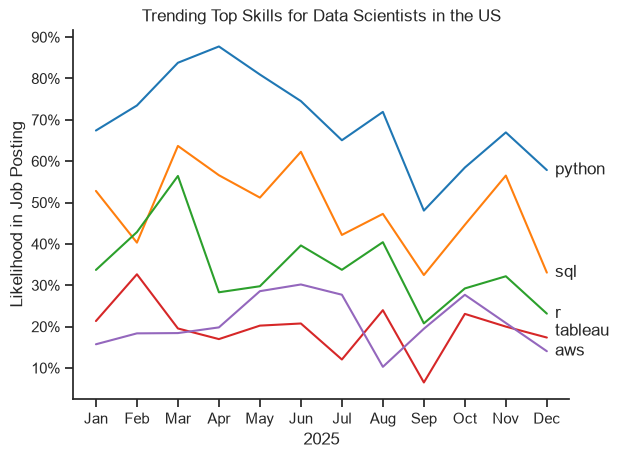

In [8]:
df_plot = df_DS_US_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Scientists in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2025')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter())

for i in range(5):
    label = df_plot.columns[i]
    y_val = df_plot.iloc[-1, i]
    
    if label == 'tableau':
        y_val += 1.5
    elif label == 'sas':
        y_val -= 1.5
        
    plt.text(11.2, y_val, label, va='center')

plt.show()
